# Factor-based regime detection

**Chapter 1 · §1.4 Keeping up with changing market regimes**

**Docker image**: `ml4t`

Markets do not behave the same way in every year. The same value strategy that earns a
steady premium through a long expansion can lose money for a decade, and the same
momentum strategy can give back years of gains in a single quarter. A **regime** is a
stretch of time over which the joint behaviour of returns is stable enough to be treated
as one environment: the averages, the volatilities and the correlations hold roughly
still inside it and shift when it ends.

Nobody publishes a regime label. This notebook estimates one from the data with a
**Gaussian mixture model** (GMM), which treats each month's vector of factor returns as
a draw from one of a small number of multivariate normal distributions and infers both
the distributions and which one each month most likely came from. The inputs are monthly
returns to nine factor strategies from AQR's Century of Factor Premia dataset, which
starts in 1927.

## Learning objectives

By the end of this notebook you will be able to:

- Fit a Gaussian mixture model to a panel of monthly factor returns and read off the
  cluster it assigns to each month.
- Choose how many clusters to keep by comparing three criteria that measure different
  things, and say what each one rewards.
- Read a regime timeline against dated market events and judge whether the clusters
  correspond to periods a reader would recognise.
- Measure what each factor earned inside each cluster, and say what that implies about
  which factors diversify each other when conditions deteriorate.
- Explain why a label fitted on the whole sample cannot be used as a trading signal.

## Book reference

Chapter 1, Section 1.4, "Keeping up with changing market regimes". `macro_regimes` is the
companion notebook and estimates regimes from macroeconomic indicators instead.

## Prerequisites

- Monthly return series and standardization (subtracting a mean, dividing by a standard
  deviation) so that series with different scales contribute comparably to a distance.
- The AQR Century of Factor Premia dataset, which `AQRFactorProvider` reads from
  `data/factors/aqr` under `ML4T_DATA_PATH`. Fetch it with
  `uv run python data/factors/aqr_download.py` if it is missing.

## What this notebook establishes, and what it does not

The model is fitted on the whole history and the labels are assigned back over that same
history. What comes out is a description of how the factor space partitions, and a way
of seeing where dated events fall inside that partition. Every month's label is informed
by every other month, including later ones, so the labels describe the sample rather than
forecast it. Building regime labels a strategy could have acted on requires walk-forward
fitting on information available at each date; Chapter 6 onward introduces that machinery
and the case-study chapters apply it.

# 以因子為基礎的市場狀態偵測

**第 1 章 · §1.4 跟上不斷變化的市場狀態**

**Docker 映像檔**:`ml4t`

市場並不是每一年的表現都相同。同一個價值策略,在漫長的擴張期裡能穩定賺取溢酬,卻也可能連續虧損十年;同一個動能策略,可能在一季之內就吐回多年的獲利。所謂**市場狀態(regime)**,是指一段報酬的聯合行為夠穩定、可以視為同一種環境的期間:在這段期間內,平均值、波動度與相關性大致維持不動,等到它結束時才發生轉變。

沒有人會公布市場狀態的標籤。本筆記本用**高斯混合模型**(Gaussian mixture model,GMM)從資料中估計出一組標籤。GMM 把每個月的因子報酬向量,視為從少數幾個多變量常態分配的其中之一抽出的樣本,並同時推論出這些分配本身,以及每個月最可能來自哪一個分配。輸入資料是 AQR「Century of Factor Premia」資料集中九個因子策略的月報酬,資料自 1927 年開始。

## 學習目標

讀完本筆記本後,你將能夠:

- 對一組月頻因子報酬的 panel 配適高斯混合模型,並讀出模型指派給每個月的群集。
- 透過比較三個衡量不同面向的準則來決定要保留幾個群集,並說明每個準則獎勵的是什麼。
- 對照有明確日期的市場事件來解讀市場狀態時間軸,並判斷這些群集是否對應到讀者認得出來的時期。
- 衡量每個因子在各個群集內賺到多少,並說明這對於「情況惡化時哪些因子能彼此分散風險」意味著什麼。
- 解釋為什麼用全樣本配適出來的標籤不能當作交易訊號。

## 書籍對照

第 1 章第 1.4 節「跟上不斷變化的市場狀態」。`macro_regimes` 是配套的筆記本,改用總體經濟指標來估計市場狀態。

## 先備知識

- 月報酬序列與標準化(減去平均數、除以標準差),讓尺度不同的序列對距離的貢獻程度相當。
- AQR Century of Factor Premia 資料集,`AQRFactorProvider` 會從 `ML4T_DATA_PATH` 底下的 `data/factors/aqr` 讀取。若資料不存在,請執行 `uv run python data/factors/aqr_download.py` 下載。

## 本筆記本確立了什麼、沒有確立什麼

模型是用整段歷史配適的,標籤也是回頭指派到同一段歷史上。得到的結果是對因子空間如何被分割的一種描述,以及一種觀察有日期的事件落在這個分割何處的方式。每個月的標籤都受到其他所有月份的影響,包括之後的月份,所以這些標籤是在描述樣本,而不是預測樣本。要建立策略當下真的能據以行動的市場狀態標籤,必須只用每個時點可取得的資訊做前推式(walk-forward)配適;第 6 章起會介紹這套機制,案例研究的章節則會實際套用。

## Setup

The AQR provider logs its download and cache decisions through `structlog`, which writes
to the notebook rather than through the standard library's logging module. Raising its
threshold to `WARNING` keeps the data-loading cells readable while leaving anything that
reports a problem visible.

## 環境設定

AQR 的資料提供者透過 `structlog` 記錄它的下載與快取決策,而 `structlog` 是直接寫到筆記本上,並不經過標準函式庫的 logging 模組。把它的門檻提高到 `WARNING`,可以讓載入資料的儲存格保持易讀,同時仍然看得到任何回報問題的訊息。

In [1]:
"""Factor-based regime detection - Gaussian mixture regimes over AQR factor returns."""

from __future__ import annotations

import logging
from collections.abc import Iterable
from dataclasses import dataclass

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import polars as pl
import structlog
from IPython.display import Markdown, display
from matplotlib.axes import Axes
from matplotlib.collections import LineCollection
from matplotlib.colors import ListedColormap
from ml4t.data.providers import AQRFactorProvider
from ml4t.diagnostic.metrics import sharpe_ratio
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.mixture import GaussianMixture
from sklearn.preprocessing import StandardScaler

import utils.style as style
from utils.paths import get_output_dir
from utils.reproducibility import set_global_seeds

structlog.configure(wrapper_class=structlog.make_filtering_bound_logger(logging.WARNING))

COLORS = style.COLORS

In [2]:
# Production defaults (Papermill overrides these when the test suite runs the notebook)
SEED = 42

### Settings, and what each one decides

`SEED` fixes the initialization of every estimator below. A Gaussian mixture is fitted by
expectation-maximization from a random start, so two runs from different starts can land
on different local optima and swap which cluster is numbered 0; fixing the seed is what
makes the figures in this notebook reproduce.

`N_REGIMES_GRID` is the set of cluster counts to fit and compare. Two is the smallest
number that partitions anything. Six is where the search stops: the point of the sweep is
to show how the criteria move as clusters are added, and by six they have already
separated.

`MONTHS_PER_YEAR` annualizes monthly statistics. Multiply a mean monthly return by it and
a monthly standard deviation by its square root.

`ROLLING_VOL_MONTHS` is the width of the moving window used to draw a volatility series.
Twelve months is short enough to move inside a regime and long enough that a single month
does not dominate the estimate.

### 各項設定,以及每一項決定了什麼

`SEED` 固定了以下每個估計器的初始化。高斯混合模型是從隨機起點以期望最大化(expectation-maximization)演算法配適的,因此從不同起點出發的兩次執行可能落在不同的局部最佳解,並且把哪個群集編號為 0 對調;固定種子才能讓本筆記本的圖表可以重現。

`N_REGIMES_GRID` 是要配適並比較的群集數集合。二是能做出任何分割的最小數目。搜尋到六為止:這次掃描的重點是呈現隨著群集增加各個準則如何變動,而到了六個時它們早已分出高下。

`MONTHS_PER_YEAR` 用來把月頻統計量年化。月平均報酬乘上它,月標準差則乘上它的平方根。

`ROLLING_VOL_MONTHS` 是繪製波動度序列時所用的移動視窗寬度。十二個月夠短,能在同一個市場狀態內有所變動;也夠長,不會讓單一個月主導估計值。

In [3]:
N_REGIMES_GRID = [2, 3, 4, 5, 6]
MONTHS_PER_YEAR = 12
ROLLING_VOL_MONTHS = 12

OUTPUT_DIR = get_output_dir(1, "factor_regimes")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

set_global_seeds(SEED)

## Load the factor panel

The AQR Century of Factor Premia dataset holds monthly returns to long-short factor
strategies built inside several asset classes, plus the returns to holding each asset
class outright. The provider returns one row per month and one column per strategy.

## 載入因子 panel

AQR Century of Factor Premia 資料集收錄了在數個資產類別內建構的多空因子策略月報酬,以及單純持有各資產類別的報酬。資料提供者回傳的資料是每個月一列、每個策略一欄。

In [4]:
aqr_raw = AQRFactorProvider().fetch("century_premia")

date_range = aqr_raw.select(
    pl.col("timestamp").min().alias("first"), pl.col("timestamp").max().alias("last")
)
print(f"AQR Century of Factor Premia: {aqr_raw.height} months, {aqr_raw.width - 1} series")
print(f"Covering {date_range['first'][0]:%Y-%m} to {date_range['last'][0]:%Y-%m}")

AQR Century of Factor Premia: 1196 months, 44 series
Covering 1926-07 to 2026-02


### The nine series used here

Four of them are cross-asset long-short strategies, applied across equity indices, bonds,
currencies and commodities at once:

- **Value** buys what is cheap relative to a fundamental anchor and sells what is
  expensive.
- **Momentum** buys what has risen over the past year and sells what has fallen.
- **Carry** buys what pays a high yield and sells what pays a low one.
- **Defensive** buys low-risk assets and sells high-risk ones.

Two apply the value and momentum definitions inside the US stock market alone. The last
three are the returns to simply holding each asset class - equity indices, fixed income,
commodities - rather than a long-short strategy, and they are what places a month in a
risk environment rather than a style environment.

### 這裡使用的九個序列

其中四個是跨資產的多空策略,同時套用在股票指數、債券、貨幣與商品上:

- **價值(Value)**:買進相對於基本面定錨而言便宜的標的,賣出昂貴的標的。
- **動能(Momentum)**:買進過去一年上漲的標的,賣出下跌的標的。
- **利差(Carry)**:買進收益率高的標的,賣出收益率低的標的。
- **防禦(Defensive)**:買進低風險資產,賣出高風險資產。

另外兩個是只在美國股市內套用價值與動能的定義。最後三個則是單純持有各資產類別(股票指數、固定收益、商品)的報酬,而非多空策略;它們的作用是把某個月定位在某種「風險環境」中,而不是某種「風格環境」中。

In [5]:
FACTOR_COLUMNS = [
    "All asset classes Value",
    "All asset classes Momentum",
    "All asset classes Carry",
    "All asset classes Defensive",
    "US Stock Selection Value",
    "US Stock Selection Momentum",
    "Equity indices Market",
    "Fixed income Market",
    "Commodities Market",
]
EQUITY_COLUMN = "Equity indices Market"

missing = [c for c in FACTOR_COLUMNS if c not in aqr_raw.columns]
if missing:
    raise ValueError(
        f"The AQR file is missing {missing}. Re-fetch it with "
        "`uv run python data/factors/aqr_download.py`."
    )

# Short names for the figures and tables below; the full AQR column names do not fit on an
# axis.
SHORT_NAMES = {
    "All asset classes Value": "Value",
    "All asset classes Momentum": "Momentum",
    "All asset classes Carry": "Carry",
    "All asset classes Defensive": "Defensive",
    "US Stock Selection Value": "US Value",
    "US Stock Selection Momentum": "US Momentum",
    "Equity indices Market": "Equity",
    "Fixed income Market": "Bonds",
    "Commodities Market": "Commodities",
}

### What is actually in the panel

Clustering treats every month as a point in nine dimensions, so a month is usable only
when all nine series are quoted. The table below reports, for each series, the month it
starts, how many observations it has, and its mean and standard deviation over the raw
file. Read it before anything computed from the panel: it says which series shortens the
usable history and how far apart the series are in scale, which is why they are
standardized before the distance is taken.

### panel 裡實際上有什麼

分群把每個月視為九維空間中的一個點,因此只有九個序列都有報價的月份才能使用。下表列出每個序列的起始月份、觀測值數量,以及在原始檔案上的平均數與標準差。在看任何由這個 panel 算出來的結果之前,請先讀這張表:它說明了哪個序列縮短了可用的歷史長度,以及各序列的尺度差距有多大,這也是為什麼在計算距離之前要先標準化。

In [6]:
coverage = pd.DataFrame(
    [
        {
            "Series": SHORT_NAMES[column],
            "First month": aqr_raw.filter(pl.col(column).is_not_null())["timestamp"].min(),
            "Months quoted": aqr_raw.select(pl.col(column).is_not_null().sum()).item(),
            "Mean (% / month)": aqr_raw.select(pl.col(column).mean()).item() * 100,
            "Std (% / month)": aqr_raw.select(pl.col(column).std()).item() * 100,
        }
        for column in FACTOR_COLUMNS
    ]
).set_index("Series")
coverage["First month"] = pd.to_datetime(coverage["First month"]).dt.strftime("%Y-%m")
coverage.style.format({"Mean (% / month)": "{:.2f}", "Std (% / month)": "{:.2f}"})

,First month,Months quoted,Mean (% / month),Std (% / month)
Series,,,,
Value,1926-07,1196,0.21,1.40
Momentum,1926-07,1196,0.30,1.64
Carry,1926-07,1196,0.20,1.30
Defensive,1926-07,1196,0.25,1.29
US Value,1926-07,1196,0.34,4.27
US Momentum,1927-01,1190,0.66,4.50
Equity,1926-07,1196,0.66,3.43
Bonds,1926-07,1196,0.12,1.11
Commodities,1926-07,1196,0.42,4.57


## Prepare the panel for clustering

Months in which any of the nine series is unquoted are dropped rather than filled. A
forward fill would repeat the previous month's return, and repeating a return is not a
missing observation recovered - it is an invented one, and a mixture model would treat it
as evidence for a cluster.

The nine series are then standardized to zero mean and unit variance. The coverage table
above shows why: the widest series in the panel has several times the monthly standard
deviation of the narrowest, and a Euclidean distance is dominated by whichever coordinate
moves furthest. Standardizing puts every series on the same footing, so the partition
reflects the direction the panel moved in rather than which column happened to be measured
on the largest scale.

## 準備用於分群的 panel

九個序列中只要有任何一個沒有報價,該月份就直接捨棄,而不做填補。向前填補(forward fill)會重複前一個月的報酬,而重複一筆報酬並不是找回一筆遺漏的觀測值,而是捏造了一筆;混合模型會把它當成支持某個群集的證據。

接著把九個序列標準化為平均數為零、變異數為一。上面的資料涵蓋表說明了原因:panel 中波動最大的序列,其月標準差是波動最小者的好幾倍,而歐氏距離會被變動幅度最大的那個座標主導。標準化讓每個序列站在相同的立足點上,因此分割結果反映的是 panel 移動的方向,而不是哪一欄碰巧以最大的尺度衡量。

In [7]:
factors_pl = aqr_raw.select(["timestamp", *FACTOR_COLUMNS]).sort("timestamp").drop_nulls()

factors_df = factors_pl.select(FACTOR_COLUMNS).to_pandas()
factors_df.index = pd.DatetimeIndex(factors_pl["timestamp"].to_pandas())

factors_scaled = StandardScaler().fit_transform(factors_df)

start_year = factors_df.index.min().year
end_year = factors_df.index.max().year
print(f"Complete months: {len(factors_df)} ({start_year} to {end_year})")

Complete months: 1190 (1927 to 2026)


## Fit a grid of mixture models

There is no test that returns the true number of regimes, so the count is a modelling
choice made by comparing candidates. The helper below fits one mixture per candidate
count and records three quantities for each.

**BIC**, the Bayesian information criterion, is the fitted log-likelihood penalised by the
number of free parameters times the log of the sample size. **AIC**, the Akaike
information criterion, applies the same idea with a constant penalty of two per parameter.
Both are better when lower, and BIC's penalty grows with the sample, so on a long panel it
is far more reluctant than AIC to buy an extra cluster. A full-covariance mixture spends
parameters quickly - each additional cluster costs a mean vector and a covariance matrix
over nine dimensions - which is what the two criteria are pricing differently.

The **silhouette score** measures something else entirely. For each month it compares the
average distance to the other months in its own cluster against the average distance to
the months of the nearest other cluster, and reports the normalized difference; the score
is the average over months. It runs from -1 to 1, it is better when higher, and a negative
value means the typical month sits closer to a different cluster than to its own. It is a
geometric statement about separation and knows nothing about likelihood.

K-means is fitted alongside for the same counts. It partitions on distance to a centroid
with no covariance and no probabilities, so putting its silhouette beside the mixture's
says how much of the separation is coming from the shape the mixture is allowed to fit.

The last two columns count things none of the three criteria look at: how often consecutive
months carry different labels, and how many months the emptiest cluster holds. A criterion
can only say how well a partition fits. Whether the partition holds still long enough to be
called a regime, and whether every cluster in it has enough months to say anything about,
are separate questions, and these two counts are the cheapest way to ask them.

## 配適一整組混合模型

沒有任何檢定能告訴我們市場狀態的真實數目,所以這個數目是一項建模上的選擇,要透過比較各個候選方案來決定。下面的輔助函式會針對每個候選群集數配適一個混合模型,並為每個模型記錄三個量。

**BIC**(貝氏資訊準則)是配適後的對數概似值,再以「自由參數個數乘以樣本數的對數」加以懲罰。**AIC**(赤池資訊準則)採用同樣的概念,但懲罰項固定為每個參數兩單位。兩者都是越低越好;BIC 的懲罰會隨樣本數增加,所以在長的 panel 上,它遠比 AIC 更不願意多買一個群集。完整共變異數的混合模型耗用參數的速度很快——在九個維度上,每多一個群集就要多付出一個平均數向量和一個共變異數矩陣——而這正是這兩個準則定價方式不同的地方。

**輪廓係數(silhouette score)** 衡量的則完全是另一回事。對每個月,它比較該月與同群集其他月份的平均距離,以及該月與最近的另一個群集各月份的平均距離,並回報正規化後的差值;整體分數則是所有月份的平均。它的範圍從 -1 到 1,越高越好,負值表示典型的月份離別的群集比離自己的群集還近。它是關於分離程度的幾何陳述,對概似值一無所知。

K-means 也針對同樣的群集數一併配適。它依據與中心點的距離來分割,沒有共變異數、也沒有機率,所以把它的輪廓係數放在混合模型的旁邊,就能看出分離程度中有多少是來自混合模型被允許配適的形狀。

最後兩欄計算的是這三個準則都不看的東西:相鄰月份帶有不同標籤的頻率,以及最空的群集裡有多少個月。準則只能說明一個分割配適得多好。至於這個分割是否維持得夠久、足以稱為市場狀態,以及其中每個群集是否都有足夠的月份可供描述,則是另外的問題,而這兩個計數是提出這些問題最便宜的方法。

In [8]:
@dataclass(frozen=True)
class GmmFitResult:
    """One fitted mixture and the three quantities used to compare it against the others."""

    model: GaussianMixture
    labels: np.ndarray
    probabilities: np.ndarray
    bic: float
    aic: float
    silhouette: float

In [9]:
def fit_gmm_grid(
    x: np.ndarray,
    n_components_list: Iterable[int],
    random_state: int = SEED,
) -> dict[int, GmmFitResult]:
    """Fit one full-covariance mixture per requested cluster count."""
    results: dict[int, GmmFitResult] = {}
    for n in n_components_list:
        model = GaussianMixture(
            n_components=n,
            covariance_type="full",
            random_state=random_state,
            n_init=10,
            reg_covar=1e-6,
        )
        model.fit(x)
        labels = model.predict(x)
        results[n] = GmmFitResult(
            model=model,
            labels=labels,
            probabilities=model.predict_proba(x),
            bic=float(model.bic(x)),
            aic=float(model.aic(x)),
            silhouette=float(silhouette_score(x, labels)),
        )
    return results

In [10]:
gmm_grid = fit_gmm_grid(factors_scaled, N_REGIMES_GRID)

kmeans_labels = {
    n: KMeans(n_clusters=n, random_state=SEED, n_init=10).fit_predict(factors_scaled)
    for n in N_REGIMES_GRID
}


def switch_count(labels: np.ndarray) -> int:
    """How many times consecutive months carry different labels."""
    return int(np.sum(np.diff(labels) != 0))


selection = pd.DataFrame(
    {
        "Clusters": N_REGIMES_GRID,
        "BIC": [gmm_grid[n].bic for n in N_REGIMES_GRID],
        "AIC": [gmm_grid[n].aic for n in N_REGIMES_GRID],
        "Silhouette (mixture)": [gmm_grid[n].silhouette for n in N_REGIMES_GRID],
        "Silhouette (k-means)": [
            silhouette_score(factors_scaled, kmeans_labels[n]) for n in N_REGIMES_GRID
        ],
        "Switches": [switch_count(gmm_grid[n].labels) for n in N_REGIMES_GRID],
        "Smallest cluster (months)": [
            int(np.bincount(gmm_grid[n].labels).min()) for n in N_REGIMES_GRID
        ],
    }
).set_index("Clusters")
selection.style.format(
    {
        "BIC": "{:,.0f}",
        "AIC": "{:,.0f}",
        "Silhouette (mixture)": "{:.3f}",
        "Silhouette (k-means)": "{:.3f}",
    }
)

,BIC,AIC,Silhouette (mixture),Silhouette (k-means),Switches,Smallest cluster (months)
Clusters,,,,,,
2,"26,391","25,837",0.288,0.234,275,263
3,"26,366","25,532",0.126,0.117,433,50
4,"26,416","25,304",0.123,0.125,450,3
5,"26,634","25,241",0.110,0.091,535,3
6,"26,820","25,148",0.036,0.078,615,6


### Reading the three criteria against each other

The bars below draw three of the table's columns. Both information criteria are drawn on a
zoomed vertical axis, because the differences between candidate models are small relative
to their level and would be invisible on a scale that started at zero; the silhouette
panel is drawn on its natural scale, which includes zero.

### 對照解讀三個準則

下方的長條圖畫出表中的三欄。兩個資訊準則都畫在放大過的縱軸上,因為各候選模型之間的差異相對於其數值水準很小,若刻度從零開始就會看不出來;輪廓係數那一格則畫在它自然的尺度上,其中包含零。

In [11]:
def plot_selection_criterion(ax: Axes, values: list[float], label: str, best: str) -> None:
    """Draw one criterion as bars, highlighting the count it favours."""
    bars = ax.bar(N_REGIMES_GRID, values, color=COLORS["recede"])
    chosen = int(np.argmin(values)) if best == "min" else int(np.argmax(values))
    bars[chosen].set_color(COLORS["amber"])
    ax.set_xlabel("Clusters")
    ax.set_ylabel(label)
    ax.set_xticks(N_REGIMES_GRID)

findfont: Failed to find font weight semibold for DejaVu Sans, now using 700.


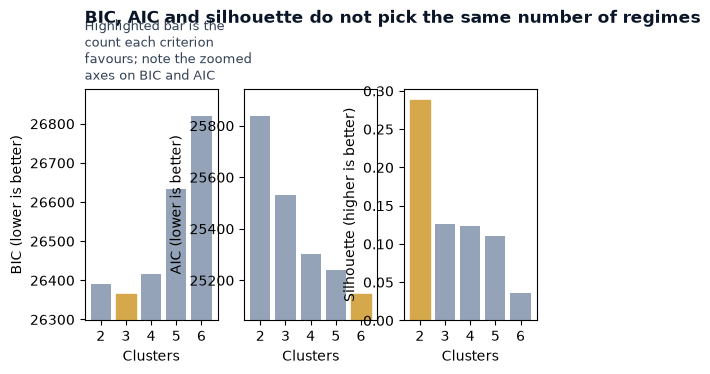

In [12]:
fig, axes = plt.subplots(1, 3, figsize=style.FIGSIZE["triple_h_tall"])

plot_selection_criterion(axes[0], selection["BIC"].tolist(), "BIC (lower is better)", "min")
plot_selection_criterion(axes[1], selection["AIC"].tolist(), "AIC (lower is better)", "min")
plot_selection_criterion(
    axes[2], selection["Silhouette (mixture)"].tolist(), "Silhouette (higher is better)", "max"
)
for ax, values in ((axes[0], selection["BIC"]), (axes[1], selection["AIC"])):
    span = values.max() - values.min()
    ax.set_ylim(values.min() - 0.15 * span, values.max() + 0.15 * span)

style.add_message_title(
    axes[0],
    "BIC, AIC and silhouette do not pick the same number of regimes",
    subtitle="Highlighted bar is the count each criterion favours; note the zoomed axes on BIC and AIC",
)
style.show_with_alt(
    fig,
    "Three bar charts over cluster counts two to six. BIC rises with the count, AIC falls "
    "with it, and the silhouette score falls sharply after the smallest count and hovers "
    "near zero at the larger ones.",
)

In [13]:
bic_choice = int(selection["BIC"].idxmin())
aic_choice = int(selection["AIC"].idxmin())
silhouette_choice = int(selection["Silhouette (mixture)"].idxmax())
display(
    Markdown(
        f"BIC is lowest at **{bic_choice} clusters** and the silhouette score is highest at "
        f"**{silhouette_choice}**, while AIC keeps falling out to **{aic_choice}**, the "
        "largest count fitted."
    )
)

BIC is lowest at **3 clusters** and the silhouette score is highest at **2**, while AIC keeps falling out to **6**, the largest count fitted.

When the criteria disagree, the choice is made on what the model is for. AIC targets
predictive likelihood and keeps buying clusters as long as they raise it, and the last two
columns say what it is buying at the larger counts: a partition that changes label more
often, containing at least one cluster with too few months to describe. A sliver of the
sample with its own covariance improves the fit and is not a regime anyone can name.

BIC's sample-scaled penalty and the silhouette's separation test both ask for clusters
distinct enough to survive being described, which is what a regime has to be if it is going
to appear in a risk report. The rest of this notebook works with the two-cluster model on
that basis, and the timelines in the next section show what the larger counts do with the
clusters they add.

當各準則意見不一致時,就依據模型的用途來做選擇。AIC 的目標是預測概似值,只要群集能提高它就會持續買進,而最後兩欄說明了它在較大的群集數下買到的是什麼:一個標籤變動更頻繁的分割,其中至少有一個群集的月份少到無從描述。一小片擁有自己共變異數的樣本確實改善了配適,但那不是任何人叫得出名字的市場狀態。

BIC 隨樣本數縮放的懲罰與輪廓係數的分離度檢驗,都要求群集夠鮮明、經得起被描述,而如果一個市場狀態要出現在風險報告裡,它就必須如此。基於這個理由,本筆記本接下來使用兩群集的模型;下一節的時間軸則呈現較多群集數的模型把新增的群集拿去做了什麼。

In [14]:
N_REGIMES_SELECTED = 2
# fit_gmm_grid fitted exactly the counts in N_REGIMES_GRID, and the swimlane and label
# cells below read gmm_grid[N_REGIMES_SELECTED]. Narrowing the grid without moving this
# constant reaches them as a KeyError.
assert N_REGIMES_SELECTED in N_REGIMES_GRID, (
    f"N_REGIMES_SELECTED={N_REGIMES_SELECTED} was never fitted; N_REGIMES_GRID={N_REGIMES_GRID}"
)

## What each cluster count partitions

Each band below is one fitted model. A month is shaded in the row of the cluster it was
assigned to, so a solid horizontal stretch is a period the model held in one regime and a
speckled stretch is one it switched through repeatedly. Comparing the bands shows what the
extra clusters buy: whether an added cluster carves out a recognisable era, or whether it
scatters across the whole century.

## 每個群集數分割出了什麼

下方每一條帶狀圖是一個配適好的模型。每個月會在它被指派到的群集那一列上著色,所以一段連續的水平色塊代表模型把那段期間維持在同一個市場狀態,斑駁的區段則代表模型在其中反覆切換。比較這些帶狀圖就能看出多出來的群集買到了什麼:新增的群集是切出了一個認得出來的時代,還是散落在整個世紀之中。

In [15]:
def decade_ticks(dates: pd.DatetimeIndex) -> tuple[list[int], list[str]]:
    """Positions and labels for the first month of each decade in a monthly index."""
    years = dates.year.tolist()
    ticks = [
        j for j, year in enumerate(years) if year % 10 == 0 and (j == 0 or years[j - 1] != year)
    ]
    return ticks, [str(years[j]) for j in ticks]

In [16]:
def draw_swimlanes(ax: Axes, rows: np.ndarray, n_rows: int, cmap: ListedColormap) -> None:
    """Shade each month in the row given by *rows*, one row per regime."""
    matrix = np.zeros((n_rows, len(rows)))
    matrix[rows, np.arange(len(rows))] = 1
    ax.imshow(
        matrix,
        aspect="auto",
        cmap=cmap,
        vmin=0,
        vmax=1,
        extent=(0, len(rows), -0.5, n_rows - 0.5),
        interpolation="nearest",
        origin="lower",
    )
    for boundary in range(1, n_rows):
        ax.axhline(y=boundary - 0.5, color=COLORS["bg_light"], linewidth=1.5)

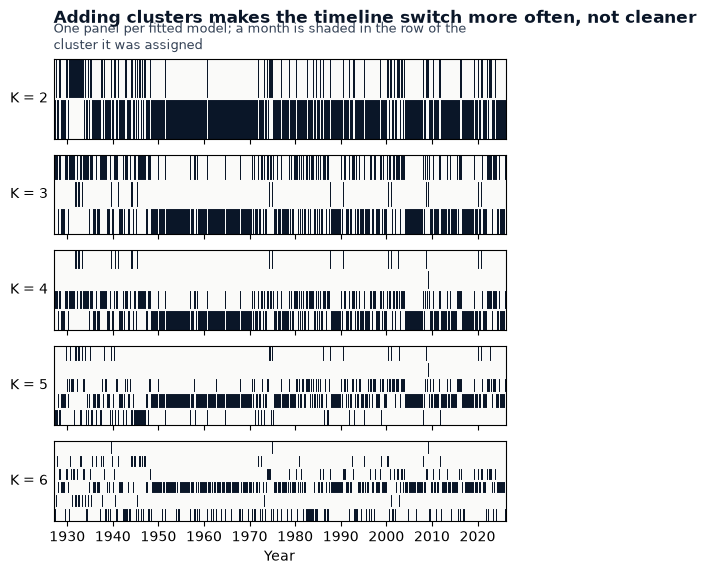

In [17]:
lane_cmap = ListedColormap([COLORS["bg_light"], COLORS["blue"]])
ticks, tick_labels = decade_ticks(factors_df.index)

fig, axes = plt.subplots(
    len(N_REGIMES_GRID),
    1,
    figsize=(style.PAGE_WIDTH, 1.0 * len(N_REGIMES_GRID) + 1.0),
    sharex=True,
)
for ax, n in zip(axes, N_REGIMES_GRID):
    draw_swimlanes(ax, gmm_grid[n].labels, n, lane_cmap)
    ax.set_yticks([])
    ax.set_ylabel(f"K = {n}", rotation=0, ha="right", va="center")

axes[-1].set_xticks(ticks)
axes[-1].set_xticklabels(tick_labels)
axes[-1].set_xlabel("Year")
style.add_message_title(
    axes[0],
    "Adding clusters makes the timeline switch more often, not cleaner",
    subtitle="One panel per fitted model; a month is shaded in the row of the cluster it was assigned",
)
style.show_with_alt(
    fig,
    "Five stacked panels, one per cluster count. The two-cluster panel shows one row "
    "occupied most of the time and the other taking short scattered stretches. Each panel "
    "below it is more finely speckled than the one above, with no row holding a long "
    "uninterrupted stretch by the largest count.",
)

No band settles down as clusters are added. An added cluster does not carve out an era the
earlier models had merged; it takes months from across the whole century, so each panel is
more finely speckled than the one above it. A mixture has no notion of time and nothing in
it prefers a month to keep its neighbour's label, so there is no mechanism by which more
clusters could produce longer stretches. That absence is the reason the last section of
the section on how long the regimes last points at a hidden Markov model, which supplies
exactly the mechanism this one lacks.

隨著群集增加,沒有任何一條帶狀圖安定下來。新增的群集並沒有切出一個先前模型合併在一起的時代;它是從整個世紀各處拿走月份,所以每一格都比上面那一格更加細碎斑駁。混合模型沒有時間的概念,其中沒有任何東西偏好讓某個月沿用鄰近月份的標籤,因此不存在任何機制能讓更多的群集產生更長的連續區段。正因為缺了這個機制,〈市場狀態能持續多久〉一節的最後才會指向隱藏式馬可夫模型(hidden Markov model),它提供的恰恰是這個模型所欠缺的機制。

## The two-cluster model: risk-on and risk-off

The mixture returns cluster numbers, not names, and the numbering carries no meaning - a
different seed can swap it. To describe the two clusters they have to be identified by
something outside the model, and the natural choice is the series that says what the
market as a whole was doing: the average return to holding equity indices inside each
cluster. **Risk-on** and **risk-off** are the market's ordinary terms for the environments
that result, meaning periods when investors were adding exposure to risky assets and
periods when they were shedding it.

Naming the clusters this way uses the whole sample, exactly as fitting them did. It is a
description of what the partition turned out to be, not a rule that could have been
applied in 1929.

## 兩群集模型:風險偏好(risk-on)與風險趨避(risk-off)

混合模型回傳的是群集編號,不是名稱,而且編號本身沒有意義——換一個種子就可能對調。要描述這兩個群集,就必須用模型以外的東西來辨識它們,而最自然的選擇是能說明整體市場當時在做什麼的那個序列:各群集內持有股票指數的平均報酬。**風險偏好(risk-on)** 與**風險趨避(risk-off)** 是市場上對由此得出的兩種環境的慣用說法,分別指投資人增加風險性資產曝險的時期,以及減少曝險的時期。

用這種方式為群集命名,和配適它們時一樣,用的是整個樣本。這是在描述分割結果最後呈現的樣貌,而不是一條在 1929 年就能套用的規則。

In [18]:
labels_2 = gmm_grid[N_REGIMES_SELECTED].labels
equity_returns = factors_df[EQUITY_COLUMN]

mean_equity_by_cluster = equity_returns.groupby(labels_2).mean()
risk_on_cluster = int(mean_equity_by_cluster.idxmax())
risk_off_cluster = int(mean_equity_by_cluster.idxmin())

regime_name = pd.Series(
    np.where(labels_2 == risk_on_cluster, "Risk-on", "Risk-off"),
    index=factors_df.index,
    name="regime",
)

### The timeline against dated events

The upper panel is the same swim-lane band as above, restricted to the two-cluster model,
with seven dated episodes marked. The lower panel is the cumulative product of the equity
index returns on a logarithmic scale, drawn in the colour of the regime each month was
assigned to. A logarithmic scale is what makes the 1930s comparable to the 2010s: equal
vertical distances are equal percentage moves, so a fall of a given percentage takes up the
same space on the axis wherever in the century it happens.

### 對照有日期事件的時間軸

上圖是和前面相同的泳道式帶狀圖,但只限於兩群集模型,並標示出七個有明確日期的事件。下圖是股票指數報酬的累積乘積,以對數刻度繪製,並依每個月被指派的市場狀態著色。對數刻度讓 1930 年代可以和 2010 年代相比:相等的垂直距離代表相等的百分比變動,所以同樣百分比的跌幅無論發生在這個世紀的哪個時點,在軸上佔的空間都一樣。

In [19]:
HISTORICAL_EVENTS = {
    1929: ("Great Crash", "top"),
    1937: ("Recession", "bottom"),
    1973: ("Oil crisis", "top"),
    1987: ("Black Monday", "bottom"),
    2000: ("Dot-com peak", "top"),
    2008: ("Global financial crisis", "bottom"),
    2020: ("COVID-19", "top"),
}

In [20]:
def mark_events(ax: Axes, years: list[int]) -> None:
    """Draw a rule and a label at the first month of each dated episode."""
    for event_year, (event_label, side) in HISTORICAL_EVENTS.items():
        position = next((j for j, year in enumerate(years) if year == event_year), None)
        if position is None:
            continue
        ax.axvline(x=position, color=COLORS["neutral"], alpha=0.6, linewidth=1.0)
        ax.annotate(
            event_label,
            xy=(position, 1.7 if side == "top" else -0.7),
            ha="center",
            va="bottom" if side == "top" else "top",
            fontsize=7,
            color=COLORS["neutral"],
        )

In [21]:
def plot_by_regime(ax: Axes, values: np.ndarray, in_risk_on: np.ndarray) -> None:
    """Draw one line whose every segment takes the colour of the month it ends in.

    The segment from month t-1 to month t is the move month t produced, so month t's regime
    is the one that colours it. Masking each regime into its own line instead would drop
    every segment that spans a transition, and would draw nothing at all for a one-month
    episode, which is most of them here.
    """
    y = np.asarray(values, dtype=float)
    points = np.column_stack([np.arange(len(y)), y]).reshape(-1, 1, 2)
    segments = np.concatenate([points[:-1], points[1:]], axis=1)
    drawable = np.isfinite(segments[:, :, 1]).all(axis=1)
    colours = np.where(in_risk_on[1:], COLORS["recede"], COLORS["blue"])
    ax.add_collection(LineCollection(segments[drawable], colors=colours[drawable], linewidths=1.2))
    finite = y[np.isfinite(y)]
    ax.set_xlim(0, len(y) - 1)
    ax.set_ylim(finite.min() * 0.9, finite.max() * 1.1)

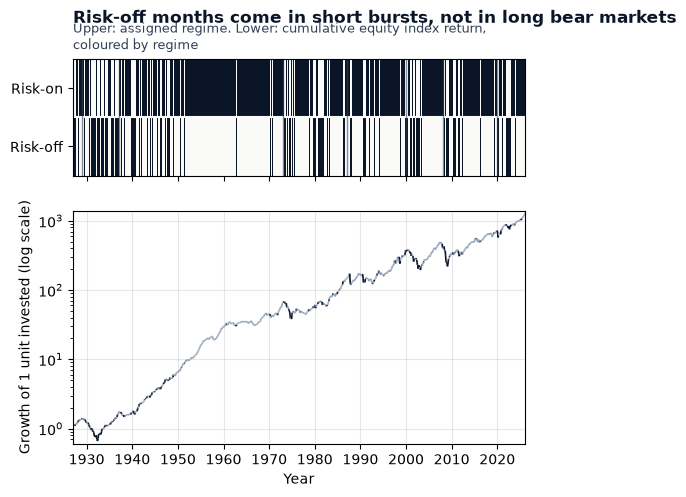

In [22]:
fig, (ax_band, ax_equity) = plt.subplots(
    2, 1, figsize=style.FIGSIZE["dual_v"], height_ratios=[1, 2], sharex=True
)

rows = np.where(labels_2 == risk_on_cluster, 1, 0)
draw_swimlanes(ax_band, rows, 2, lane_cmap)
ax_band.set_yticks([0, 1])
ax_band.set_yticklabels(["Risk-off", "Risk-on"])
ax_band.set_ylim(-0.5, 1.5)
mark_events(ax_band, factors_df.index.year.tolist())

cumulative = (1 + equity_returns).cumprod()
in_risk_on = labels_2 == risk_on_cluster
plot_by_regime(ax_equity, cumulative.to_numpy(), in_risk_on)
ax_equity.set_yscale("log")
ax_equity.set_ylabel("Growth of 1 unit invested (log scale)")
ax_equity.set_xlabel("Year")
ax_equity.set_xticks(ticks)
ax_equity.set_xticklabels(tick_labels)
ax_equity.grid(True, alpha=0.3)

style.add_message_title(
    ax_band,
    "Risk-off months come in short bursts, not in long bear markets",
    subtitle="Upper: assigned regime. Lower: cumulative equity index return, coloured by regime",
)
style.show_with_alt(
    fig,
    "A two-row regime band above a rising cumulative return curve on a log scale. The "
    "risk-off row is occupied in many short bursts spread across the whole century rather "
    "than in a few long blocks, and the curve is drawn dark through those same stretches.",
)

## Volatility inside each regime

A regime label is only worth carrying if it corresponds to something a risk manager would
act on, and the first thing to check is whether the two environments differ in how much
the market moves. The series below is the standard deviation of the equity index return
over a trailing twelve-month window, annualized by multiplying by the square root of
twelve, drawn in the colour of the regime assigned to each month. The dashed rules are the
average of that rolling series within each regime.

## 各市場狀態內的波動度

市場狀態標籤要值得保留,必須對應到風險管理者會據以行動的東西,而首先要檢查的,就是這兩種環境在市場波動幅度上是否有差異。下方的序列是股票指數報酬在過去十二個月滾動視窗內的標準差,乘以十二的平方根加以年化,並依每個月被指派的市場狀態著色。虛線是該滾動序列在各市場狀態內的平均值。

In [23]:
rolling_vol = equity_returns.rolling(ROLLING_VOL_MONTHS).std() * np.sqrt(MONTHS_PER_YEAR)

rolling_vol_by_regime = (
    rolling_vol.groupby(regime_name)
    .agg(["mean", "median", "max"])
    .rename(columns={"mean": "Mean (%)", "median": "Median (%)", "max": "Max (%)"})
    .mul(100)
    .loc[["Risk-on", "Risk-off"]]
)
rolling_vol_by_regime.index.name = "Regime"
rolling_vol_by_regime.style.format("{:.1f}")

,Mean (%),Median (%),Max (%)
Regime,,,
Risk-on,9.8,8.6,31.4
Risk-off,12.6,10.8,31.8


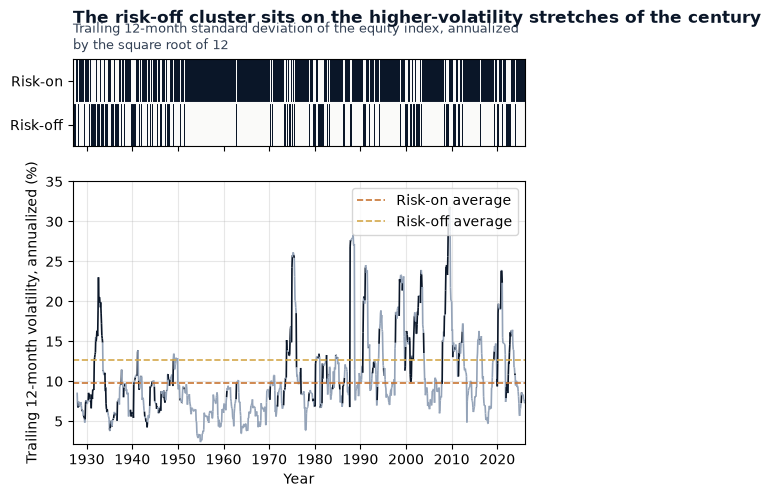

In [24]:
fig, (ax_band, ax_vol) = plt.subplots(
    2, 1, figsize=style.FIGSIZE["dual_v"], height_ratios=[1, 3], sharex=True
)

draw_swimlanes(ax_band, rows, 2, lane_cmap)
ax_band.set_yticks([0, 1])
ax_band.set_yticklabels(["Risk-off", "Risk-on"])
ax_band.set_ylim(-0.5, 1.5)

plot_by_regime(ax_vol, rolling_vol.to_numpy() * 100, in_risk_on)
for regime, colour in (("Risk-on", COLORS["copper"]), ("Risk-off", COLORS["amber"])):
    ax_vol.axhline(
        rolling_vol_by_regime.loc[regime, "Mean (%)"],
        color=colour,
        linestyle="--",
        linewidth=1.2,
        label=f"{regime} average",
    )
ax_vol.set_ylabel(f"Trailing {ROLLING_VOL_MONTHS}-month volatility, annualized (%)")
ax_vol.set_xlabel("Year")
ax_vol.set_xticks(ticks)
ax_vol.set_xticklabels(tick_labels)
ax_vol.legend(loc="upper right")
ax_vol.grid(True, alpha=0.3)

style.add_message_title(
    ax_band,
    "The risk-off cluster sits on the higher-volatility stretches of the century",
    subtitle=f"Trailing {ROLLING_VOL_MONTHS}-month standard deviation of the equity index, "
    f"annualized by the square root of {MONTHS_PER_YEAR}",
)
style.show_with_alt(
    fig,
    "A two-row regime band above a rolling volatility series in percent. The dark risk-off "
    "segments concentrate on the peaks of the volatility series, and the risk-off average "
    "rule sits above the risk-on one.",
)

### Figure 1.5 inputs

The print version of Figure 1.5 is drawn by
`book/01_process_is_edge/figures/scripts/generate_figure_1_5_factor_regimes_volatility.py`
in the book repository. It reads the arrays written below, so the book build renders the
figure from this notebook's fit rather than re-estimating the mixture.

### 圖 1.5 的輸入資料

圖 1.5 的印刷版本是由書籍儲存庫中的
`book/01_process_is_edge/figures/scripts/generate_figure_1_5_factor_regimes_volatility.py`
繪製的。它會讀取下面寫出的陣列,所以書籍的建置流程是根據本筆記本的配適結果來繪圖,而不是重新估計混合模型。

In [25]:
ARTIFACT_DIR = OUTPUT_DIR / "figure_1_5"
ARTIFACT_DIR.mkdir(parents=True, exist_ok=True)
np.savez(
    ARTIFACT_DIR / "inputs.npz",
    dates=factors_df.index.astype("datetime64[ns]").astype("int64"),
    labels_2=np.asarray(labels_2, dtype=np.int64),
    good_regime=np.int64(risk_on_cluster),
    rolling_vol=rolling_vol.to_numpy(dtype=float),
    risk_on_mean_vol=float(rolling_vol_by_regime.loc["Risk-on", "Mean (%)"]) / 100,
    risk_off_mean_vol=float(rolling_vol_by_regime.loc["Risk-off", "Mean (%)"]) / 100,
    start_year=np.int64(start_year),
    end_year=np.int64(end_year),
)

## What each factor earned in each regime

The volatility check says the two environments differ in how much the market moved. The
more useful question for portfolio construction is whether the strategies behave
differently in them, because a strategy that earns its premium in both is a diversifier
and one that only earns it in the calm environment is leverage on the market in disguise.

Each bar below is the mean monthly return of one series over the months assigned to one
regime, multiplied by twelve. This is an average within a set of months, not the return of
a strategy that switched between them - no rule available in real time would have produced
this partition.

## 每個因子在各市場狀態中賺到多少

波動度的檢查告訴我們,這兩種環境在市場波動幅度上有所不同。對投資組合建構來說更有用的問題是:各策略在這兩種環境中的表現是否不同。因為在兩種環境中都能賺到溢酬的策略是分散風險的工具,而只在平靜環境中賺到溢酬的策略,不過是偽裝過的市場槓桿。

下方每一根長條,是某個序列在被指派到某個市場狀態的月份中的平均月報酬,再乘以十二。這是一組月份內的平均,而不是一個在兩種狀態之間切換的策略所得到的報酬——沒有任何即時可用的規則能產生這樣的分割。

In [26]:
annualized_by_regime = (
    factors_df.groupby(regime_name).mean().mul(MONTHS_PER_YEAR * 100).rename(columns=SHORT_NAMES)
).loc[["Risk-on", "Risk-off"]]

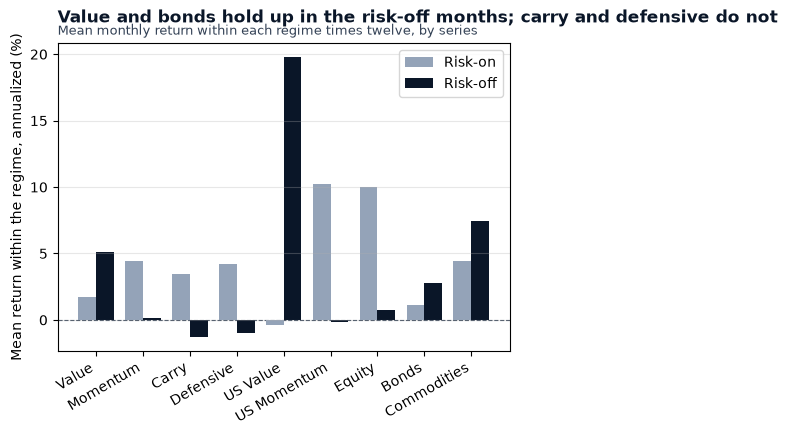

In [27]:
fig, ax = plt.subplots(figsize=style.FIGSIZE["single_tall"])

x = np.arange(annualized_by_regime.shape[1])
width = 0.38
ax.bar(
    x - width / 2,
    annualized_by_regime.loc["Risk-on"],
    width,
    label="Risk-on",
    color=COLORS["recede"],
)
ax.bar(
    x + width / 2,
    annualized_by_regime.loc["Risk-off"],
    width,
    label="Risk-off",
    color=COLORS["blue"],
)
ax.set_xticks(x)
ax.set_xticklabels(annualized_by_regime.columns, rotation=30, ha="right")
ax.set_ylabel("Mean return within the regime, annualized (%)")
style.zero_line(ax)
ax.legend(loc="upper right")
ax.grid(axis="y", alpha=0.3)

style.add_message_title(
    ax,
    "Value and bonds hold up in the risk-off months; carry and defensive do not",
    subtitle="Mean monthly return within each regime times twelve, by series",
)
style.show_with_alt(
    fig,
    "Paired bars per factor. Value and bonds have taller risk-off bars than risk-on bars; "
    "momentum, equity, carry and defensive have taller risk-on bars, with carry and "
    "defensive falling below zero in the risk-off months.",
)

In [28]:
annualized_by_regime.T.style.format("{:+.1f}")

regime,Risk-on,Risk-off
Value,+1.7,+5.1
Momentum,+4.5,+0.1
Carry,+3.5,-1.3
Defensive,+4.2,-1.0
US Value,-0.4,+19.8
US Momentum,+10.2,-0.2
Equity,+10.0,+0.7
Bonds,+1.1,+2.7
Commodities,+4.4,+7.4


The two strategies a calm market reads as safe income - carry, which collects a yield
spread, and defensive, which is long low-risk assets - are the ones that stop paying when
conditions deteriorate. Value and bonds go the other way and earn more.

A strategy's average return over a full sample therefore says nothing about whether it
will be there in the environment a portfolio needs it in. Finding out means conditioning
on the environment and looking, which is what makes a regime label worth estimating even
when nothing can act on it.

在平靜的市場裡被視為安全收益來源的兩個策略——收取收益率利差的利差策略,以及做多低風險資產的防禦策略——正是情況惡化時停止賺錢的策略。價值與債券則相反,反而賺得更多。

因此,一個策略在全樣本上的平均報酬,完全無法說明在投資組合需要它的環境裡它是否還靠得住。要找出答案,就必須以環境為條件實際去看,這也是為什麼即使無法據以行動,市場狀態標籤仍然值得估計。

## Regime statistics

The table below characterises each regime through the equity index alone. Every statistic
is computed on one stream: the monthly returns of the months the model assigned to that
regime, concatenated in date order with the months in the other regime removed.

For the mean, the standard deviation and the Sharpe ratio that is an ordinary conditional
statistic - the average of a set of months does not depend on their order. **Maximum
drawdown** is different, because it is a path statistic: it compounds the stream, tracks
its running high-water mark, and reports the largest percentage fall from that mark to a
later point. Compounding a stream whose gaps have been closed up is not the same as
compounding the index, so the number below describes an investor who held equities during
one regime and held nothing during the other. The section after the table shows how far
apart the two readings are.

## 市場狀態統計量

下表只透過股票指數來刻畫每個市場狀態。每個統計量都是在單一一條序列上計算的:把模型指派到該市場狀態的月份的月報酬,依日期順序串接起來,並移除屬於另一個狀態的月份。

對平均數、標準差與夏普比率而言,這是普通的條件統計量——一組月份的平均值與它們的順序無關。**最大回撤(maximum drawdown)** 則不同,因為它是路徑統計量:它把序列複利累積,追蹤其歷史高水位線,並回報從該高點到之後某一點的最大百分比跌幅。把一條缺口已被接合的序列複利累積,並不等同於把指數本身複利累積,所以下面的數字描述的是一位只在其中一個狀態期間持有股票、在另一個狀態期間什麼都不持有的投資人。表格之後的小節會說明這兩種解讀的差距有多大。

In [29]:
def drawdown_path(returns: pd.Series) -> pd.Series:
    """Fractional decline from the running high-water mark of the compounded stream."""
    wealth = (1 + returns).cumprod()
    return wealth / wealth.cummax() - 1

In [30]:
regime_statistics = pd.DataFrame(
    [
        {
            "Regime": regime,
            "Months": int(len(returns)),
            "Share of sample": len(returns) / len(equity_returns),
            "Return, annualized": returns.mean() * MONTHS_PER_YEAR,
            "Volatility, annualized": returns.std() * np.sqrt(MONTHS_PER_YEAR),
            "Sharpe ratio": sharpe_ratio(returns, periods_per_year=MONTHS_PER_YEAR),
            "Max drawdown": float(drawdown_path(returns).min()),
        }
        for regime, returns in (
            (name, equity_returns[regime_name == name]) for name in ("Risk-on", "Risk-off")
        )
    ]
).set_index("Regime")
regime_statistics.style.format(
    {
        "Share of sample": "{:.1%}",
        "Return, annualized": "{:+.1%}",
        "Volatility, annualized": "{:.1%}",
        "Sharpe ratio": "{:.2f}",
        "Max drawdown": "{:.1%}",
    }
)

,Months,Share of sample,"Return, annualized","Volatility, annualized",Sharpe ratio,Max drawdown
Regime,,,,,,
Risk-on,927,77.9%,+10.0%,8.6%,1.17,-24.3%
Risk-off,263,22.1%,+0.7%,19.4%,0.04,-83.5%


In [31]:
pooled_vol_ratio = (
    regime_statistics.loc["Risk-off", "Volatility, annualized"]
    / regime_statistics.loc["Risk-on", "Volatility, annualized"]
)
rolling_vol_ratio = (
    rolling_vol_by_regime.loc["Risk-off", "Mean (%)"]
    / rolling_vol_by_regime.loc["Risk-on", "Mean (%)"]
)
display(
    Markdown(
        f"Risk-off volatility is **{pooled_vol_ratio:.2f}x** risk-on volatility measured on "
        f"the pooled monthly returns, against **{rolling_vol_ratio:.2f}x** measured as the "
        "average of the trailing twelve-month series."
    )
)

Risk-off volatility is **2.26x** risk-on volatility measured on the pooled monthly returns, against **1.29x** measured as the average of the trailing twelve-month series.

The two ratios answer different questions and a reader should expect them to differ. The
rolling series smooths each month against the eleven around it, so a single extreme month
raises twelve windows a little; the pooled standard deviation lets it enter once, at full
size. The pooled figure is the one that describes what a portfolio holding through the
regime experiences, and the rolling figure is the one a monitoring dashboard would show.
Reporting either alone would be defensible; reporting one and calling it "the" volatility
ratio would not.

這兩個比率回答的是不同的問題,讀者應該預期它們會不一樣。滾動序列把每個月和它周圍的十一個月一起平滑,所以單一個極端月份會把十二個視窗各拉高一點;合併計算的標準差則讓它以完整的幅度進入一次。合併計算的數字描述的是在整個市場狀態期間持續持有的投資組合所經歷的情況,而滾動的數字則是監控儀表板上會顯示的。只報告其中任何一個都說得過去;但只報告一個卻把它稱為「唯一的」波動度比率,就說不過去了。

### What the restricted drawdown actually measures

The drawdown reported for the risk-off regime is large, and it is worth reading where it
came from before quoting it. The cell below finds the high-water mark of the restricted
stream and the month it fell furthest below it, and puts the drawdown of the index itself
over the same span beside it.

### 受限回撤實際衡量的是什麼

風險趨避狀態所回報的回撤很大,在引用它之前,值得先弄清楚它是怎麼來的。下面的儲存格會找出受限序列的高水位線,以及它跌到該高點以下最深的那個月,並把指數本身在同一段期間的回撤放在旁邊對照。

In [32]:
risk_off_returns = equity_returns[regime_name == "Risk-off"]
risk_off_drawdown = drawdown_path(risk_off_returns)
trough_month = risk_off_drawdown.idxmin()
peak_month = (1 + risk_off_returns).cumprod().loc[:trough_month].idxmax()

restricted_drawdown = float(risk_off_drawdown.min())
index_over_span = equity_returns.loc[peak_month:trough_month]
index_drawdown = float(drawdown_path(index_over_span).min())
display(
    Markdown(
        f"The restricted stream peaks in **{peak_month:%B %Y}** and reaches its low in "
        f"**{trough_month:%B %Y}**, a fall of "
        f"**{abs(restricted_drawdown):.1%}** spread over "
        f"**{trough_month.year - peak_month.year} years**. Over the same span the equity "
        f"index itself fell at most **{abs(index_drawdown):.1%}** from its own high-water "
        "mark."
    )
)

The restricted stream peaks in **May 1986** and reaches its low in **March 2020**, a fall of **83.5%** spread over **34 years**. Over the same span the equity index itself fell at most **55.4%** from its own high-water mark.

Nobody lived through the first of those two numbers. The risk-off months are selected by
the mixture's assignment, not by the sign of the equity return, so the stream holds gains
as well as losses - its average monthly return is positive. What it does not hold is the
months in between, and closing those gaps puts a loss from one decade immediately beside a
loss from the next, with none of the recovery that separated them. Compounded, decades of
separate episodes read as one uninterrupted decline.

The statistic is not wrong; it is the correct drawdown of the object it was computed on.
But the object is a construction of this notebook, and a reader who takes it for a crash
has been misled by a table that never said which object it meant.

That is the general form: a conditional statistic inherits the assumptions of the
conditioning. Averages survive it, because a mean does not care in what order its terms
arrive. Anything that reads a path - a drawdown, a run length, a time to recovery, a
stop-loss - is a different statistic once the path has been cut up, and reporting it
without saying so is how a number that means one thing gets read as another.

沒有人真的經歷過這兩個數字中的第一個。風險趨避的月份是依混合模型的指派挑出來的,而不是依股票報酬的正負號,所以這條序列裡既有上漲也有下跌——它的平均月報酬是正的。它所沒有的是中間的那些月份;把這些缺口接合起來,就讓某個十年的虧損緊接著下一個十年的虧損,而原本把它們隔開的復甦完全不見了。複利累積之後,數十年間各自獨立的事件看起來就像一段不間斷的下跌。

這個統計量並沒有錯;就它所計算的對象而言,它是正確的回撤。但這個對象是本筆記本建構出來的東西,如果讀者把它當成一次崩盤,那就是被一張從未說明它指的是哪個對象的表格誤導了。

這就是一般性的結論:條件統計量會繼承條件設定本身的假設。平均數不受影響,因為平均數不在乎各項以什麼順序出現。但任何要讀取路徑的東西——回撤、連續期間長度、復原所需時間、停損——一旦路徑被切開,就成了另一個統計量;報告它卻不加說明,就是讓一個意思是這樣的數字被讀成另一個意思的原因。

## How long the regimes last

A regime label is useful to a strategy only if it persists long enough to act on. An
**episode** below is a maximal run of consecutive months carrying the same label, and the
table reports how many episodes each regime had and how long they ran.

## 市場狀態能持續多久

市場狀態標籤要對策略有用,必須持續得夠久才來得及據以行動。下面所謂的**區段(episode)**,是指帶有相同標籤的連續月份所構成的最長連續期間;表格列出每個市場狀態有幾個區段,以及它們各持續多久。

In [33]:
episode_id = (labels_2 != np.roll(labels_2, 1)).cumsum()
episode_lengths = (
    pd.DataFrame({"regime": regime_name.to_numpy(), "episode": episode_id})
    .groupby(["regime", "episode"])
    .size()
    .rename("months")
    .reset_index()
)

duration = (
    episode_lengths.groupby("regime")["months"]
    .agg(["mean", "max", "count"])
    .rename(
        columns={"mean": "Mean length (months)", "max": "Longest (months)", "count": "Episodes"}
    )
    .loc[["Risk-on", "Risk-off"]]
)
duration.index.name = "Regime"
duration.style.format({"Mean length (months)": "{:.1f}"})

,Mean length (months),Longest (months),Episodes
Regime,,,
Risk-on,6.7,110,138
Risk-off,1.9,14,138


In [34]:
switches = int(np.sum(np.diff(labels_2) != 0))
months_between_switches = len(labels_2) / switches
display(
    Markdown(
        f"The two-cluster model changes regime **{switches}** times over "
        f"{end_year - start_year} years, about once every "
        f"**{months_between_switches:.1f} months**."
    )
)

The two-cluster model changes regime **275** times over 99 years, about once every **4.3 months**.

That is the finding that decides what this model is for. A label that changes several
times a year cannot drive a reallocation: the turnover would be paid on every switch,
including the ones the model reverses a month later, and the transaction costs would
arrive whether or not the regime call was right. The same label is useful as a lens on
history and as one input to a risk report, which is the use Section 1.4 argues for.

A model built to be acted on would be built differently. It would carry a transition
structure that makes staying in a regime more likely than leaving it - a hidden Markov
model is the standard choice - and it would be fitted forward in time so that each
month's label used only the months before it. `09_model_based_features/11_hmm_regimes`
builds the first, and `09_model_based_features/13_regime_as_feature` turns the result into
a feature a model downstream can read.

這項發現決定了這個模型的用途。一年變動好幾次的標籤無法驅動資產重新配置:每次切換都要付出周轉成本,包括那些模型一個月後就反轉的切換,而且不論市場狀態判斷得對不對,交易成本都會發生。同一個標籤作為檢視歷史的透鏡、以及作為風險報告的一項輸入,則是有用的,這也正是第 1.4 節所主張的用途。

一個為了據以行動而打造的模型,做法會不一樣。它會帶有一個轉移結構,使得留在某個狀態的機率高於離開它——隱藏式馬可夫模型是標準的選擇——而且它會沿著時間向前配適,讓每個月的標籤只用到它之前的月份。`09_model_based_features/11_hmm_regimes` 建構前者,`09_model_based_features/13_regime_as_feature` 則把結果轉成下游模型可以讀取的特徵。

## Key takeaways

- **The number of clusters is a decision, not an estimate.** BIC, AIC and the silhouette
  score reward different things, so they will disagree; pick the one whose objective
  matches what the labels are for, and say which you picked and why.
- **Cluster numbers carry no meaning until something outside the model names them.** Here
  the average equity return within each cluster does the naming, and a different seed can
  renumber the clusters without changing the partition.
- **Condition on the environment before trusting a factor's average.** A strategy's
  full-sample premium can be entirely earned in one environment, which is invisible in the
  pooled number and decisive for whether it diversifies anything.
- **State how a conditional statistic was built.** Restricting a return stream to the
  months in a regime and concatenating them produces a drawdown no investor experienced
  unless they held only during that regime; the same number is either informative or
  misleading depending on whether that construction is stated.
- **Fitting on the whole sample buys description, not prediction.** Every label here is
  informed by the months after it, so the labels cannot be used as features. Walk-forward
  fitting is what makes them usable, and Chapter 6 onward introduces it.

**Known limitations.** The mixture has no notion of time: it can assign January 1932 and
January 2019 to the same cluster and has no mechanism preferring a month to keep the
previous month's label, which is why the episodes are short. The AQR series are monthly, so
nothing here resolves anything faster than a month. And the panel is a century long, over
which the composition of the asset classes and the microstructure of the markets changed
considerably; the model treats 1927 and 2024 as draws from the same set of distributions.

**Next**: `macro_regimes` asks the same question of macroeconomic indicators rather than
factor returns, and checks the resulting clusters against realized equity volatility.

## 重點整理

- **群集的數目是一項決策,不是一個估計值。** BIC、AIC 與輪廓係數獎勵的東西不同,所以它們會意見不一;請挑選目標與標籤用途相符的那一個,並說明你選了哪個、為什麼。
- **在模型以外的東西為它們命名之前,群集編號沒有任何意義。** 這裡是用各群集內的平均股票報酬來命名,而換一個種子可能會重新編號群集,但不會改變分割本身。
- **在相信一個因子的平均值之前,先以環境為條件來看。** 一個策略的全樣本溢酬可能全部是在某一種環境中賺到的,這在合併的數字裡看不出來,卻對它究竟有沒有分散任何風險具有決定性。
- **說明條件統計量是怎麼建構的。** 把報酬序列限制在某個市場狀態的月份並串接起來,會產生一個沒有投資人經歷過的回撤,除非他們只在該狀態期間持有;同一個數字是有資訊價值還是誤導人,取決於有沒有說明這個建構方式。
- **用全樣本配適買到的是描述,不是預測。** 這裡每個標籤都受到它之後月份的影響,所以這些標籤不能當作特徵使用。前推式(walk-forward)配適才能讓它們變得可用,第 6 章起會加以介紹。

**已知限制。** 混合模型沒有時間的概念:它可以把 1932 年 1 月和 2019 年 1 月指派到同一個群集,也沒有任何機制偏好讓某個月沿用前一個月的標籤,這就是區段很短的原因。AQR 的序列是月頻的,所以這裡無法解析任何比一個月更快的變化。此外,這個 panel 長達一個世紀,期間各資產類別的組成與市場的微結構都有相當大的變化;模型卻把 1927 年和 2024 年視為從同一組分配中抽出的樣本。

**接下來**:`macro_regimes` 改用總體經濟指標而非因子報酬來問同一個問題,並用已實現的股票波動度來檢驗所得到的群集。